<a href="https://colab.research.google.com/github/Palee222/Shallow-Models-Training-Validation-and-Tuning/blob/main/assisnment_2_%3CLauraSomogyi%3E.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Welcome to my second assignment :)***

*   I enjoyed working on it very much
*   I would do more like this in the future
*   during the summer break I will do my own project
    *   A model recoginizing my writing and transform it to a text on a computer which I can copy or paste anywhere. This would be only personal use


In [37]:
#here I import some basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import seaborn as sns
import warnings as wr
wr.filterwarnings('ignore')
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

#Task 1

In [38]:
data = pd.read_csv("hour.csv")
data
#loading the data here

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,17375,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,11,108,119
17375,17376,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,8,81,89
17376,17377,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90
17377,17378,2012-12-31,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,13,48,61


In [39]:
data.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [4]:
data.shape

(17379, 17)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [6]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
instant,17379.0,8690.000000,5017.029500,1.00,4345.5000,8690.0000,13034.5000,17379.0000
season,17379.0,2.501640,1.106918,1.00,2.0000,3.0000,3.0000,4.0000
yr,17379.0,0.502561,0.500008,0.00,0.0000,1.0000,1.0000,1.0000
mnth,17379.0,6.537775,3.438776,1.00,4.0000,7.0000,10.0000,12.0000
hr,17379.0,11.546752,6.914405,0.00,6.0000,12.0000,18.0000,23.0000
holiday,17379.0,0.028770,0.167165,0.00,0.0000,0.0000,0.0000,1.0000
weekday,17379.0,3.003683,2.005771,0.00,1.0000,3.0000,5.0000,6.0000
workingday,17379.0,0.682721,0.465431,0.00,0.0000,1.0000,1.0000,1.0000
weathersit,17379.0,1.425283,0.639357,1.00,1.0000,1.0000,2.0000,4.0000
temp,17379.0,0.496987,0.192556,0.02,0.3400,0.5000,0.6600,1.0000


In [7]:
data.columns.tolist()
#This converts the column names of the DataFrame into a Python list making it easy to access and manipulate the column names.

['instant',
 'dteday',
 'season',
 'yr',
 'mnth',
 'hr',
 'holiday',
 'weekday',
 'workingday',
 'weathersit',
 'temp',
 'atemp',
 'hum',
 'windspeed',
 'casual',
 'registered',
 'cnt']

In [8]:
#checking for missing values
data.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [9]:
#number of duplicate rows
data.duplicated().sum()

np.int64(0)

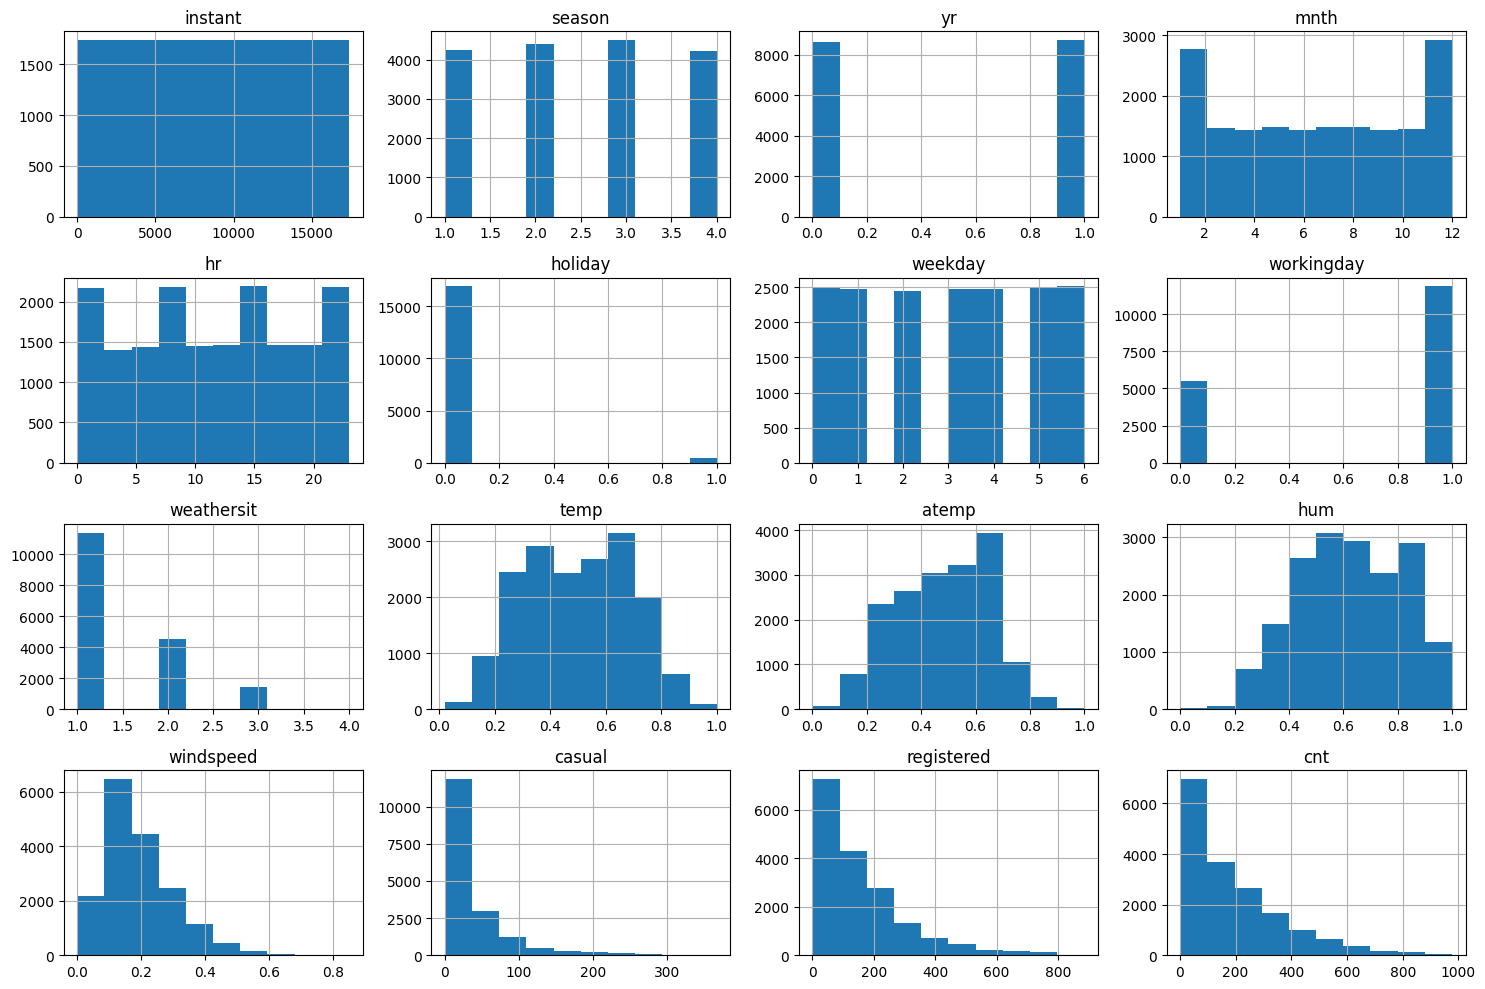

In [10]:
data.hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

In [11]:
#here I get the description of the count data
data['cnt'].describe()

,cnt
count,17379.000000
mean,189.463088
std,181.387599
min,1.000000
25%,40.000000
50%,142.000000
75%,281.000000
max,977.000000


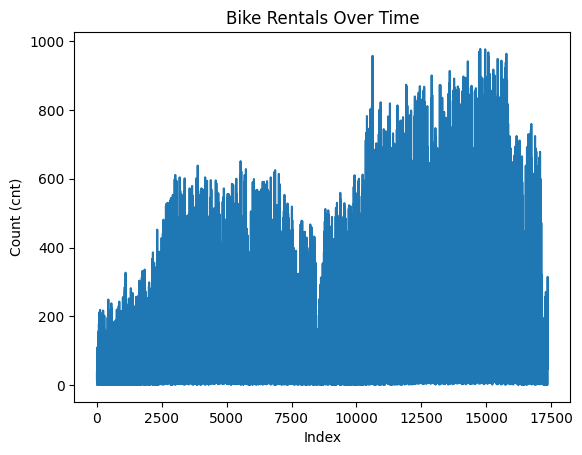

In [40]:
#here I just plot count over time
plt.plot(data['cnt'])
plt.xlabel('Index')
plt.ylabel('Count (cnt)')
plt.title('Bike Rentals Over Time')
plt.show()

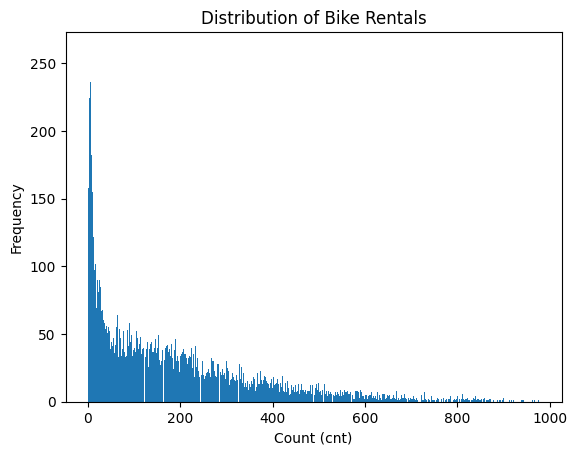

In [13]:
#here is a second plot jut in case
plt.hist(data['cnt'], bins=1000)
plt.xlabel('Count (cnt)')
plt.ylabel('Frequency')
plt.title('Distribution of Bike Rentals')
plt.show()

From the second diagram it seems like the count variable is left skewed. However from the first plot it seems like a sligth right skewedness.

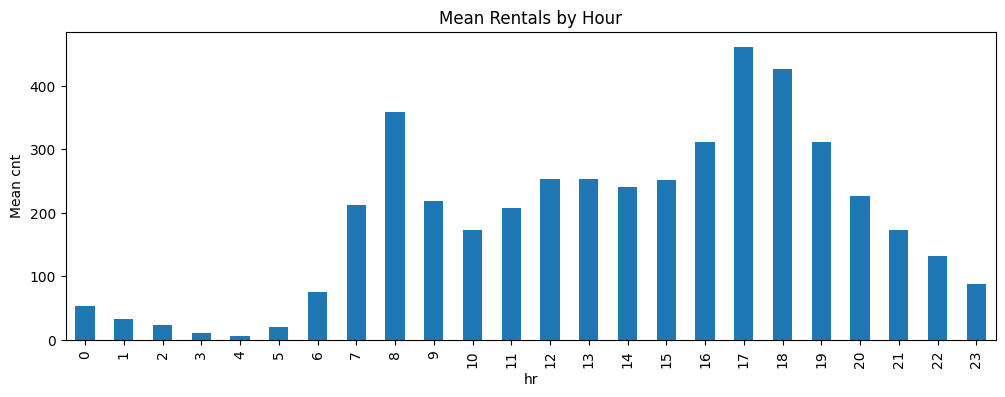

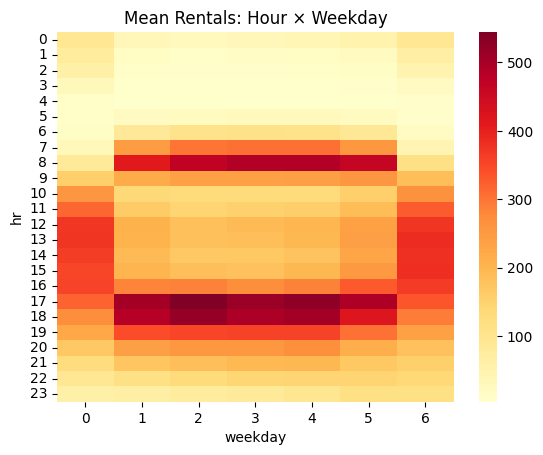

ANOVA for hr: F=759.09, p=0.0000


In [41]:
#temporal data influence (hour and weekdays)
data.groupby('hr')['cnt'].mean().plot(kind='bar', figsize=(12,4), title='Mean Rentals by Hour')
plt.ylabel('Mean cnt'); plt.show()

pivot = data.pivot_table(values='cnt', index='hr', columns='weekday', aggfunc='mean')
sns.heatmap(pivot, cmap='YlOrRd')
plt.title('Mean Rentals: Hour × Weekday'); plt.show()

#Anova
groups = [group['cnt'].values for _, group in data.groupby('hr')]
f_stat, p_value = stats.f_oneway(*groups)
print(f"ANOVA for hr: F={f_stat:.2f}, p={p_value:.4f}")

On the first plot, I have plotted out the mean number rentals by hour. People mainly rent bikes at 8 a.m. or 5-6 p.m. which may be due to the rush hour to work and/or school.

Also, added a heatmap with the hours and days represented at the same time. This also visualises that on the weekdays (day 1 to 5) people rent more bikes than the rest of the time.

So, overall I would say that hour and weekdays do have influence on the count of bike rentals. In addition there are outliers in this hourly and daily relationship and those are which I indentified above at 8 am and 5-6 pm

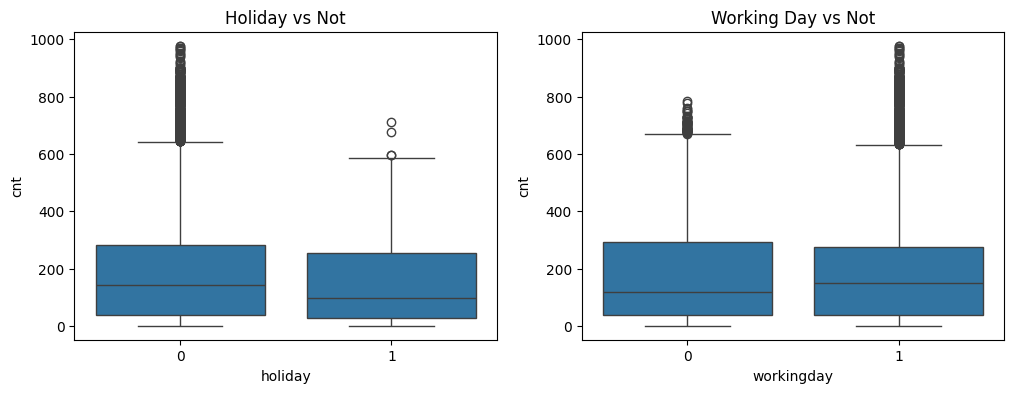

t-test workingday: t=3.99, p=0.0001


In [42]:
#binary data
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x='holiday',    y='cnt', data=data, ax=axes[0]).set_title('Holiday vs Not')
sns.boxplot(x='workingday', y='cnt', data=data, ax=axes[1]).set_title('Working Day vs Not')
plt.show()

#t-test for workingday
working     = data[data['workingday'] == 1]['cnt']
not_working = data[data['workingday'] == 0]['cnt']
t_stat, p_val = stats.ttest_ind(working, not_working)
print(f"t-test workingday: t={t_stat:.2f}, p={p_val:.4f}")

Here due to visible outliers on the "hoilday vs not" on non-holiday people rent more bicikles than on not holiday days. Also, on working days people seemingly tend to rend more as on the boxplot.

temp         0.404772
atemp        0.400929
hum         -0.322911
windspeed    0.093234
Name: cnt, dtype: float64


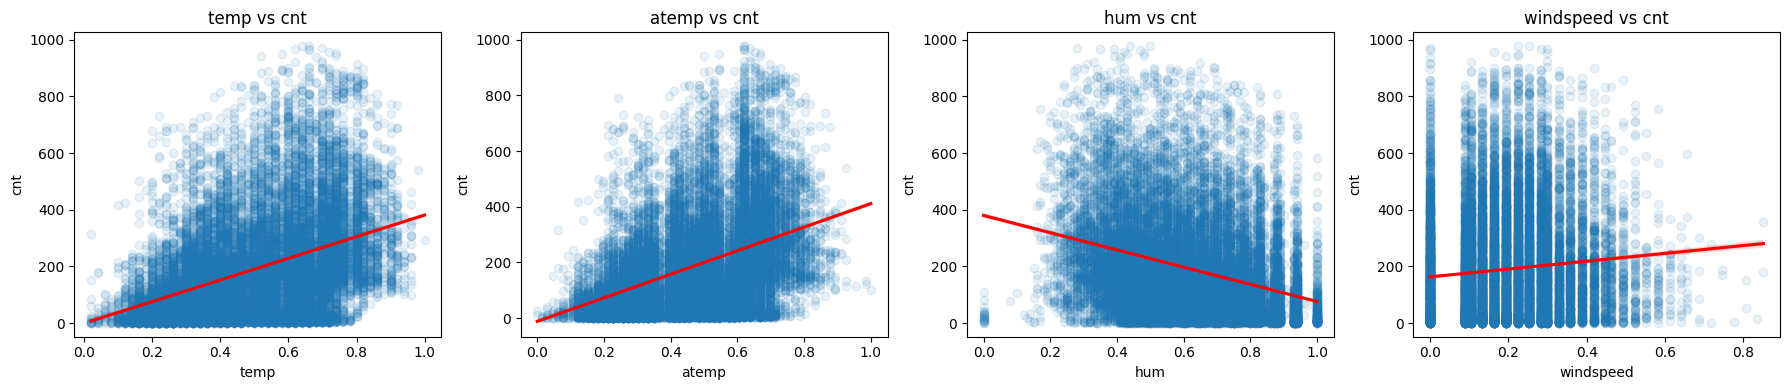

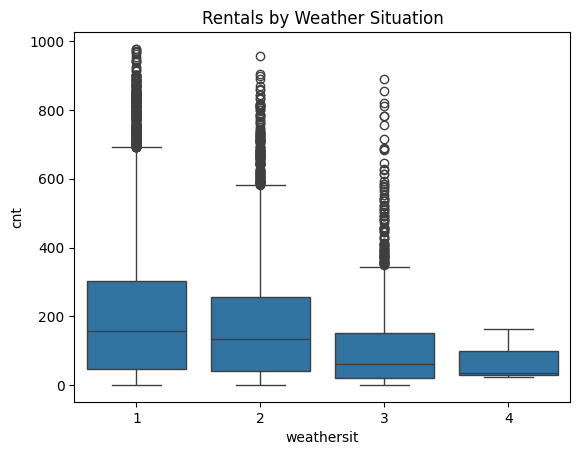

ANOVA weathersit: F=127.17, p=0.0000


In [43]:
#weateher feautre
#Correlation table
weather_cols = ['temp', 'atemp', 'hum', 'windspeed', 'cnt']
print(data[weather_cols].corr(method='pearson')['cnt'].drop('cnt'))

#Scatter plots with regression line
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, ['temp', 'atemp', 'hum', 'windspeed']):
    sns.regplot(x=col, y='cnt', data=data, ax=ax, scatter_kws={'alpha':0.1}, line_kws={'color':'red'})
    ax.set_title(f'{col} vs cnt')
plt.tight_layout(); plt.show()

sns.boxplot(x='weathersit', y='cnt', data=data)
plt.title('Rentals by Weather Situation'); plt.show()

# ANOVA
groups = [g['cnt'].values for _, g in data.groupby('weathersit')]
f, p = stats.f_oneway(*groups)
print(f"ANOVA weathersit: F={f:.2f}, p={p:.4f}")

The drops in the following column were just to see what would happen an not really to actually implement it so I commented them out. I will handle later on the variables that need dropping.

In [17]:
'''
dataset = data.drop(columns=["instant", "dteday", "casual", "registered"], axis=1, errors='ignore')
#but in the end I did not drop the columns, just tested how it would look like so I will keep on using 'data' as my souce, but if needed I used a new variable name if I want
# to use the dropped parts
dataset.describe()
'''

'\ndataset = data.drop(columns=["instant", "dteday", "casual", "registered"], axis=1, errors=\'ignore\')\n#but in the end I did not drop the columns, just tested how it would look like so I will keep on using \'data\' as my souce, but if needed I used a new variable name if I want\n# to use the dropped parts\ndataset.describe()\n'

In [18]:
'''
dataset.hist(figsize=(15, 10))
plt.tight_layout()
plt.show()
'''

'\ndataset.hist(figsize=(15, 10))\nplt.tight_layout()\nplt.show()\n'

#Task 2 - data splitting

In [19]:
# Define features (X) and target (y)
X = data.drop('cnt', axis=1)
y = data['cnt']

In [20]:
from sklearn.model_selection import train_test_split

# Split the data into training (60%) and a temporary set (40%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)

# Split the temporary set into validation and test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Training set size: {len(X_train)} samples")
print(f"Validation set size: {len(X_val)} samples")
print(f"Test set size: {len(X_test)} samples")

Training set size: 10427 samples
Validation set size: 3476 samples
Test set size: 3476 samples


#Task 3 - feature engineeing

In [21]:
# Encode 'hr' (hour) as cyclical features
data['hr_sin'] = np.sin(2 * np.pi * data['hr'] / 24)
data['hr_cos'] = np.cos(2 * np.pi * data['hr'] / 24)

# Encode 'weekday' as cyclical features
data['weekday_sin'] = np.sin(2 * np.pi * data['weekday'] / 7)
data['weekday_cos'] = np.cos(2 * np.pi * data['weekday'] / 7)

print("Cyclical features added to dataset:")
print(data[['hr', 'hr_sin', 'hr_cos', 'weekday', 'weekday_sin', 'weekday_cos']].head())

Cyclical features added to dataset:
   hr    hr_sin    hr_cos  weekday  weekday_sin  weekday_cos
0   0  0.000000  1.000000        6    -0.781831      0.62349
1   1  0.258819  0.965926        6    -0.781831      0.62349
2   2  0.500000  0.866025        6    -0.781831      0.62349
3   3  0.707107  0.707107        6    -0.781831      0.62349
4   4  0.866025  0.500000        6    -0.781831      0.62349


In [22]:
# One-hot encode categorical features: 'season', 'weathersit', 'mnth'
dataset2 = pd.get_dummies(data, columns=['season', 'weathersit', 'mnth'], drop_first=True, dtype=int)

print("One-hot encoded features added to dataset:")
print(data.head())

One-hot encoded features added to dataset:
   instant      dteday  season  yr  mnth  hr  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1   0        0        6           0   
1        2  2011-01-01       1   0     1   1        0        6           0   
2        3  2011-01-01       1   0     1   2        0        6           0   
3        4  2011-01-01       1   0     1   3        0        6           0   
4        5  2011-01-01       1   0     1   4        0        6           0   

   weathersit  ...   atemp   hum  windspeed  casual  registered  cnt  \
0           1  ...  0.2879  0.81        0.0       3          13   16   
1           1  ...  0.2727  0.80        0.0       8          32   40   
2           1  ...  0.2727  0.80        0.0       5          27   32   
3           1  ...  0.2879  0.75        0.0       3          10   13   
4           1  ...  0.2879  0.75        0.0       0           1    1   

     hr_sin    hr_cos  weekday_sin  weekday_cos  
0  0.

In [23]:
from sklearn.preprocessing import StandardScaler

# Define the continuous features to scale
continuous_features = ['temp', 'atemp', 'hum', 'windspeed']

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling to the selected features in dataset2
dataset2[continuous_features] = scaler.fit_transform(dataset2[continuous_features])

print("Scaled continuous features in dataset2 (first 5 rows):")
print(dataset2[continuous_features].head())
print("\nDescription of scaled features:")
print(dataset2[continuous_features].describe())

Scaled continuous features in dataset2 (first 5 rows):
       temp     atemp       hum  windspeed
0 -1.334648 -1.093281  0.947372  -1.553889
1 -1.438516 -1.181732  0.895539  -1.553889
2 -1.438516 -1.181732  0.895539  -1.553889
3 -1.334648 -1.093281  0.636370  -1.553889
4 -1.334648 -1.093281  0.636370  -1.553889

Description of scaled features:
               temp         atemp           hum     windspeed
count  1.737900e+04  1.737900e+04  1.737900e+04  1.737900e+04
mean   1.569989e-16 -1.831654e-16 -3.074562e-16  1.537281e-16
std    1.000029e+00  1.000029e+00  1.000029e+00  1.000029e+00
min   -2.477205e+00 -2.768625e+00 -3.251166e+00 -1.553889e+00
25%   -8.153035e-01 -8.290895e-01 -7.631431e-01 -6.996886e-01
50%    1.564696e-02  5.251758e-02  1.436398e-02  3.189880e-02
75%    8.465975e-01  8.462549e-01  7.918711e-01  5.198962e-01
max    2.612367e+00  3.050563e+00  1.932215e+00  5.399871e+00


In [44]:
#Create copies to work with to avoid modifying original X_train, X_val, X_test
X_train_processed = X_train.copy()
X_val_processed = X_val.copy()
X_test_processed = X_test.copy()

#Drop irrelevant columns from all splits
cols_to_drop = ["instant", "dteday", "casual", "registered"]
X_train_processed = X_train_processed.drop(columns=cols_to_drop, errors='ignore')
X_val_processed = X_val_processed.drop(columns=cols_to_drop, errors='ignore')
X_test_processed = X_test_processed.drop(columns=cols_to_drop, errors='ignore')

#One-hot encode categorical features: 'season', 'weathersit', 'mnth'
categorical_features = ['season', 'weathersit', 'mnth']

X_train_processed = pd.get_dummies(X_train_processed, columns=categorical_features, drop_first=True, dtype=int)

X_val_processed = pd.get_dummies(X_val_processed, columns=categorical_features, drop_first=True, dtype=int)
X_test_processed = pd.get_dummies(X_test_processed, columns=categorical_features, drop_first=True, dtype=int)

train_cols = X_train_processed.columns
X_val_processed = X_val_processed.reindex(columns=train_cols, fill_value=0)
X_test_processed = X_test_processed.reindex(columns=train_cols, fill_value=0)

#Scale continuous features: 'temp', 'atemp', 'hum', 'windspeed'
continuous_features = ['temp', 'atemp', 'hum', 'windspeed']

scaler = StandardScaler()

scaler.fit(X_train_processed[continuous_features])

X_train_processed[continuous_features] = scaler.transform(X_train_processed[continuous_features])
X_val_processed[continuous_features] = scaler.transform(X_val_processed[continuous_features])
X_test_processed[continuous_features] = scaler.transform(X_test_processed[continuous_features])

#Create Interaction Terms
#Interaction between 'temp' (continuous) and 'workingday' (binary)
X_train_processed['temp_x_workingday'] = X_train_processed['temp'] * X_train_processed['workingday']
X_val_processed['temp_x_workingday'] = X_val_processed['temp'] * X_val_processed['workingday']
X_test_processed['temp_x_workingday'] = X_test_processed['temp'] * X_test_processed['workingday']

#Interaction between 'temp' and 'weathersit_2'
X_train_processed['temp_x_weathersit_2'] = X_train_processed['temp'] * X_train_processed['weathersit_2']
X_val_processed['temp_x_weathersit_2'] = X_val_processed['temp'] * X_val_processed['weathersit_2']
X_test_processed['temp_x_weathersit_2'] = X_test_processed['temp'] * X_test_processed['weathersit_2']

#interaction term between temp*humidity
X_train_processed['temp_x_humidity'] = X_train_processed['temp'] * X_train_processed['hum']
X_val_processed['temp_x_humidity'] = X_val_processed['temp'] * X_val_processed['hum']
X_test_processed['temp_x_humidity'] = X_test_processed['temp'] * X_test_processed['hum']

#Remove redundant features based on VIF analysis
features_to_remove = ['atemp']
X_train_processed = X_train_processed.drop(columns=features_to_remove, errors='ignore')
X_val_processed = X_val_processed.drop(columns=features_to_remove, errors='ignore')
X_test_processed = X_test_processed.drop(columns=features_to_remove, errors='ignore')


print("Processed Training Features (first 5 rows with new interaction terms and 'atemp' removed):")
print(X_train_processed.head())
print("\nProcessed Validation Features (first 5 rows with new interaction terms and 'atemp' removed):")
print(X_val_processed.head())
print("\nProcessed Test Features (first 5 rows with new interaction terms and 'atemp' removed):")
print(X_test_processed.head())

print(f"\nShape of X_train_processed: {X_train_processed.shape}")
print(f"Shape of X_val_processed: {X_val_processed.shape}")
print(f"Shape of X_test_processed: {X_test_processed.shape}")

Processed Training Features (first 5 rows with new interaction terms and 'atemp' removed):
       yr  hr  holiday  weekday  workingday      temp       hum  windspeed  \
3219    0   1        0        4           1  0.010779  1.617165  -1.553977   
14197   1  18        0        0           0  0.737229  0.789210  -0.698230   
6282    0   8        0        6           0  0.425893  1.410176  -0.820246   
16019   1   4        0        1           1 -1.027007 -0.556216   0.523563   
7449    0   0        0        6           0 -1.338343 -0.142239  -0.454199   

       season_2  season_3  ...  mnth_6  mnth_7  mnth_8  mnth_9  mnth_10  \
3219          1         0  ...       0       0       0       0        0   
14197         0         1  ...       0       0       1       0        0   
6282          0         0  ...       0       0       0       1        0   
16019         0         0  ...       0       0       0       0        0   
7449          0         0  ...       0       0       0       0   

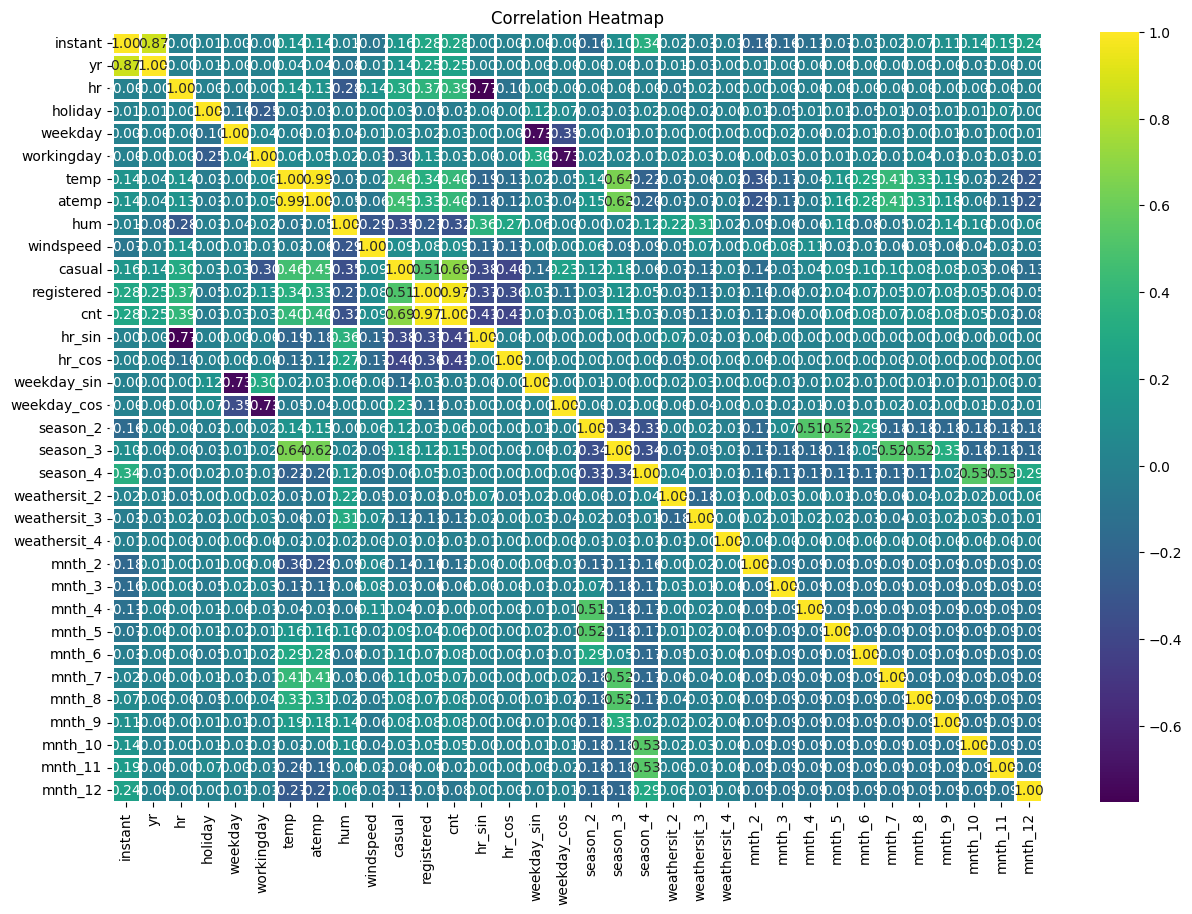

In [25]:
plt.figure(figsize=(15, 10))

sns.heatmap(dataset2.corr(numeric_only=True), annot=True, fmt='.2f', cmap='viridis', linewidths=2)

plt.title('Correlation Heatmap')
plt.show()

Temp and humidity has 0.99 correlation

In [45]:
X_vif_data = X_train_processed.copy()

X_vif_data = add_constant(X_vif_data, has_constant='add')

vif_results = pd.DataFrame(columns=['feature', 'VIF'])

for i in range(X_vif_data.shape[1]):
    feature_name = X_vif_data.columns[i]
    try:
        vif_score = variance_inflation_factor(X_vif_data.values, i)
        vif_results.loc[i] = [feature_name, vif_score]
    except Exception as e:
        vif_results.loc[i] = [feature_name, f"Calculation Error: {e}"]

vif_results = vif_results.sort_values(by='VIF', ascending=False, ignore_index=True)

print("Variance Inflation Factor (VIF) scores for X_train_processed features:")
print(vif_results)

Variance Inflation Factor (VIF) scores for X_train_processed features:
                feature        VIF
0                 const  35.342414
1              season_3  10.547417
2                mnth_7   8.422550
3                mnth_8   8.081264
4              season_2   7.445387
5                  temp   7.414442
6              season_4   7.383707
7                mnth_5   6.408194
8                mnth_6   6.406460
9                mnth_9   6.091889
10              mnth_10   5.512344
11               mnth_4   5.314528
12              mnth_11   4.936222
13              mnth_12   3.199772
14    temp_x_workingday   3.057106
15               mnth_3   2.558274
16               mnth_2   1.829249
17                  hum   1.635564
18  temp_x_weathersit_2   1.393726
19         weathersit_3   1.275423
20      temp_x_humidity   1.227646
21                   hr   1.179852
22            windspeed   1.179624
23         weathersit_2   1.175728
24              holiday   1.098729
25           workin

By the VIF I would remove const and season_3 since it's VIF is very high compared to other features and VIF>10 high correlation between features and is cause for concern.

Also, maybe I would also concider removing mnth_9, mnth_6, mnth_5, mnth_4, mnth_7, mnth_8, temp and season_2 because of VIF>5 features are highly correlated.

#Task 4 - base line model, linear regession

python -m pip install numpy scikit-learn statsmodels

In [27]:
# Initialize the Linear Regression model
model = LinearRegression()

# Fit the model using the pre-processed training data
model.fit(X_train_processed, y_train)

print("Model is ready for prediction")

Model is ready for prediction


In [28]:
# Make predictions on the validation set
y_pred_val = model.predict(X_val_processed)

# Calculate Mean Squared Error (MSE) using the validation set
mse = mean_squared_error(y_val, y_pred_val)

print(f"Mean Squared Error on Validation Set: {mse:.2f}")

Mean Squared Error on Validation Set: 18606.12


In [29]:
# Mean Absolute Error on validation set
mae = mean_absolute_error(y_val, y_pred_val)

print(f"Mean Absolute Error on Validation Set: {mae:.2f}")

Mean Absolute Error on Validation Set: 100.89


In [30]:
#R2 score
r2 = r2_score(y_val, y_pred_val)
print(f"R2 Score on Validation Set: {r2:.2f}")

R2 Score on Validation Set: 0.43


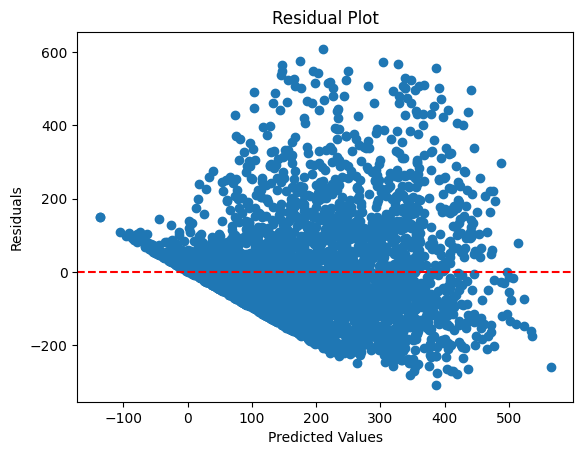

In [31]:
#Plot the residuals
residuals = y_val - y_pred_val
plt.scatter(y_pred_val, residuals)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.axhline(y=0, color='r', linestyle='--')
plt.show()

Analysis on this plot

- Seemingly from the plot there is a straight line between the residual and predicted values between 200.

In [32]:
#bias and variance characteristics
bias = np.mean(y_pred_val - y_val)
variance = np.var(y_pred_val)

print(f"Bias: {bias:.2f}")
print(f"Variance: {variance:.2f}")

Bias: 2.51
Variance: 13888.21


As of bias, the dataset is slightly biased, but I would not say that it is very biased in any direction.

Regarding variance, it has a huge variance in the number of bike rentals.


#Task 5
- Train a Random Forest Regressor.
- Use default or initial parameters (e.g., 100 trees, no depth limit) to establish a baseline.
- Evaluate using the same metrics as above.
- Compare with the baseline model and explain observed differences.
- Include at least a feature importance plot and comment on top predictors

Random Forest Regressor model trained successfully.

Random Forest Regressor Performance on Validation Set:
Mean Squared Error (MSE): 1866.34
Mean Absolute Error (MAE): 26.15
R2 Score: 0.94

Comparison with Linear Regression Baseline:
Linear Regression MSE: 18606.12, Random Forest MSE: 1866.34
Linear Regression MAE: 100.89, Random Forest MAE: 26.15
Linear Regression R2: 0.43, Random Forest R2: 0.94


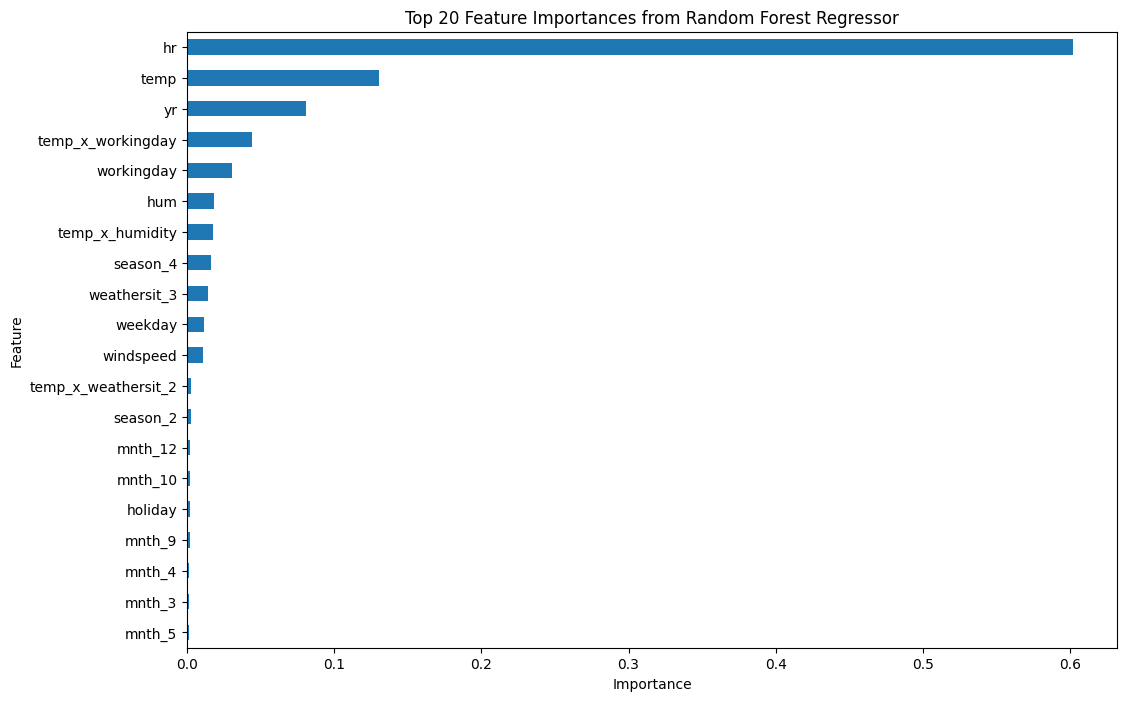

In [46]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

rf_model.fit(X_train_processed, y_train)

print("Random Forest Regressor model trained successfully.")

y_pred_val_rf = rf_model.predict(X_val_processed)

mse_rf = mean_squared_error(y_val, y_pred_val_rf)
mae_rf = mean_absolute_error(y_val, y_pred_val_rf)
r2_rf = r2_score(y_val, y_pred_val_rf)

print(f"\nRandom Forest Regressor Performance on Validation Set:")
print(f"Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"R2 Score: {r2_rf:.2f}")

print("\nComparison with Linear Regression Baseline:")
print(f"Linear Regression MSE: {mse:.2f}, Random Forest MSE: {mse_rf:.2f}")
print(f"Linear Regression MAE: {mae:.2f}, Random Forest MAE: {mae_rf:.2f}")
print(f"Linear Regression R2: {r2:.2f}, Random Forest R2: {r2_rf:.2f}")

feature_importances = pd.Series(rf_model.feature_importances_, index=X_train_processed.columns)

plt.figure(figsize=(12, 8))
feature_importances.sort_values(ascending=False).head(20).plot(kind='barh')
plt.title('Top 20 Feature Importances from Random Forest Regressor')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.gca().invert_yaxis()


#Task 6
Gradient Boosting Regressor - Model Specification and Training

• Train a Gradient Boosting Regressor (e.g., XGBoost or LightGBM)


• Use basic parameters to establish initial results.


• Plot at least residuals and compare performance with previous models.


• Note any early signs of overfitting or high variance

Gradient Boosting Regressor model trained successfully.

Gradient Boosting Regressor Performance on Validation Set:
Mean Squared Error (MSE): 5140.77
Mean Absolute Error (MAE): 48.31
R2 Score: 0.84

Comparison with Linear Regression and Random Forest Baseline:
Linear Regression MSE: 18606.12, MAE: 100.89, R2: 0.43
Random Forest MSE: 1866.34, MAE: 26.15, R2: 0.94
Gradient Boosting MSE: 5140.77, MAE: 48.31, R2: 0.84


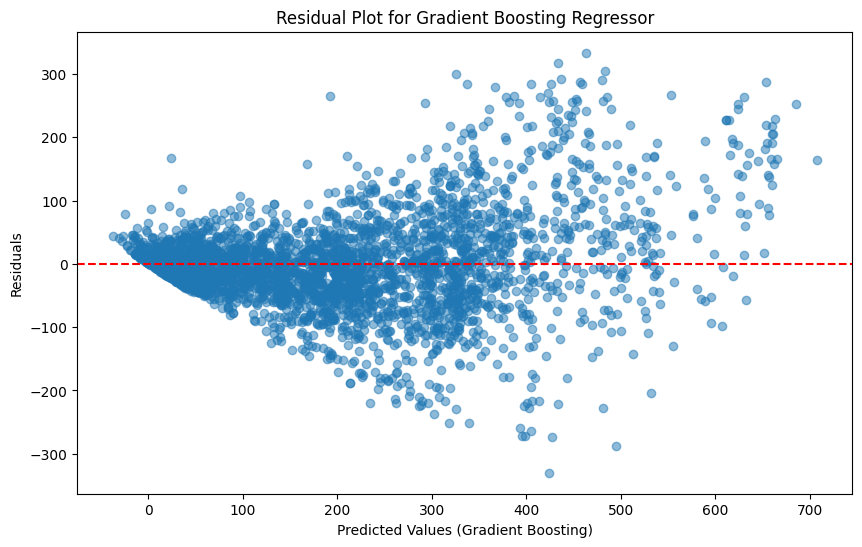

In [49]:
from sklearn.ensemble import GradientBoostingRegressor
gbr_model = GradientBoostingRegressor(random_state=42)

# Fit the model using the pre-processed training data
gbr_model.fit(X_train_processed, y_train)

print("Gradient Boosting Regressor model trained successfully.")

# Make predictions on the validation set
y_pred_val_gbr = gbr_model.predict(X_val_processed)

# Calculate evaluation metrics
mse_gbr = mean_squared_error(y_val, y_pred_val_gbr)
mae_gbr = mean_absolute_error(y_val, y_pred_val_gbr)
r2_gbr = r2_score(y_val, y_pred_val_gbr)

print(f"\nGradient Boosting Regressor Performance on Validation Set:")
print(f"Mean Squared Error (MSE): {mse_gbr:.2f}")
print(f"Mean Absolute Error (MAE): {mae_gbr:.2f}")
print(f"R2 Score: {r2_gbr:.2f}")

# Compare with previous models
print("\nComparison with Linear Regression and Random Forest Baseline:")
print(f"Linear Regression MSE: {mse:.2f}, MAE: {mae:.2f}, R2: {r2:.2f}")
print(f"Random Forest MSE: {mse_rf:.2f}, MAE: {mae_rf:.2f}, R2: {r2_rf:.2f}")
print(f"Gradient Boosting MSE: {mse_gbr:.2f}, MAE: {mae_gbr:.2f}, R2: {r2_gbr:.2f}")

# Plot the residuals
residuals_gbr = y_val - y_pred_val_gbr
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_val_gbr, residuals_gbr, alpha=0.5)
plt.xlabel("Predicted Values (Gradient Boosting)")
plt.ylabel("Residuals")
plt.title("Residual Plot for Gradient Boosting Regressor")
plt.axhline(y=0, color='r', linestyle='--')
plt.show()

#Task 7
Hyperparameter Tuning

• Tune the Random Forest Regressor:

    – Use Randomized Search CV with 5-fold cross-validation.
    – Tune the following hyperparameters: n estimators, max depth, min samples split, min samples leaf.
    – Report: best parameter combination, validation performance, updated feature importance.
• Tune the Gradient Boosting Regressor:

    – Use Bayesian Optimization (e.g., via BayesSearchCV).
    –Tune: learning rate, n estimators, max depth, subsample.
    – Visualize convergence of the optimizer if possible.
    – Report: best parameters, cross-validated performance, impact of tuning on generalization.


• Explain whether tuning significantly improved performance or not, and hypothesize why (e.g., model variance, overfitting, flat loss surface, etc.)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Randomized Search completed for Random Forest Regressor.

Best parameters found: {'max_depth': 19, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 104}
Best cross-validated MSE (negative, so lower is better): -2358.30

Tunned Random Forest Regressor Performance on Validation Set:
Mean Squared Error (MSE): 1966.06
Mean Absolute Error (MAE): 27.09
R2 Score: 0.94

Comparison with Linear Regression, original Random Forest, and Gradient Boosting:
Linear Regression MSE: 18606.12, MAE: 100.89, R2: 0.43
Random Forest (Original) MSE: 1866.34, MAE: 26.15, R2: 0.94
Gradient Boosting MSE: 5140.77, MAE: 48.31, R2: 0.84
Random Forest (Tuned) MSE: 1966.06, MAE: 27.09, R2: 0.94


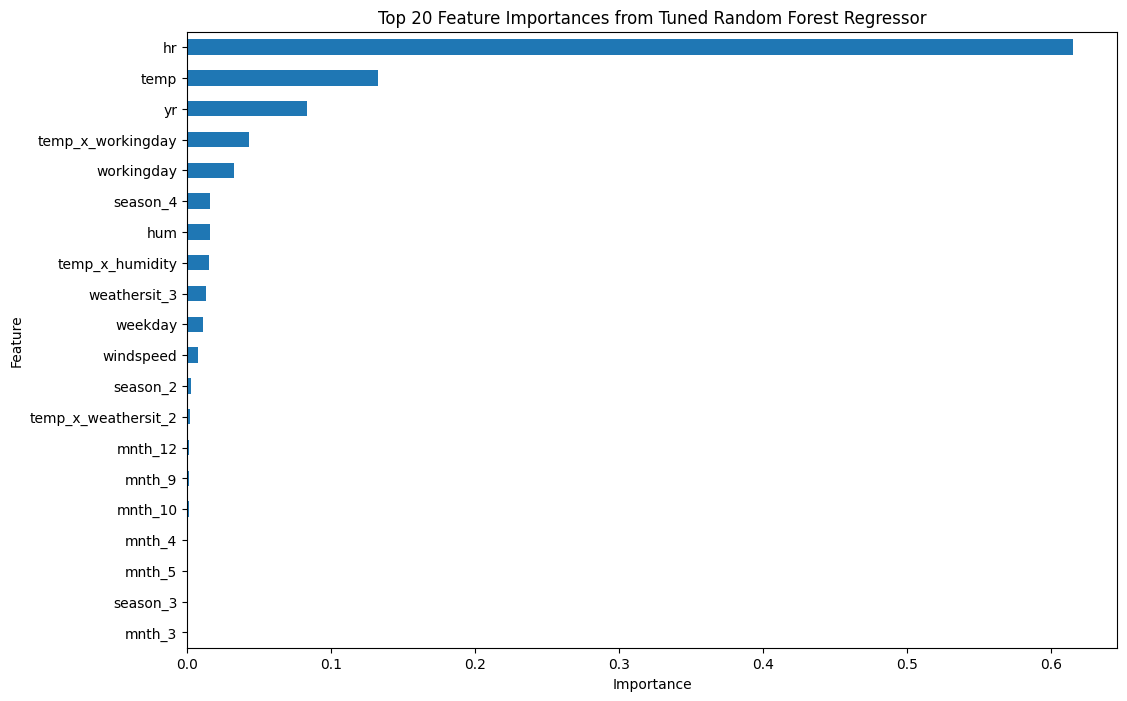

In [50]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import randint, uniform

# Define the parameter distribution for RandomizedSearchCV
param_dist_rf = {
    'n_estimators': randint(50, 200),
    'max_depth': randint(10, 30),     # Reduced range for maximum depth of the tree
    'min_samples_split': randint(2, 10), # Reduced range for min samples to split
    'min_samples_leaf': randint(1, 10)  # Reduced range for min samples at a leaf node
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

rf_random = RandomizedSearchCV(estimator=rf, param_distributions=param_dist_rf,
                               n_iter=10, cv=5, verbose=2, random_state=42, n_jobs=-1, scoring='neg_mean_squared_error')

rf_random.fit(X_train_processed, y_train)

print("Randomized Search completed for Random Forest Regressor.")

print(f"\nBest parameters found: {rf_random.best_params_}")
print(f"Best cross-validated MSE (negative, so lower is better): {rf_random.best_score_:.2f}")

best_rf_model = rf_random.best_estimator_
y_pred_val_rf_tuned = best_rf_model.predict(X_val_processed)

mse_rf_tuned = mean_squared_error(y_val, y_pred_val_rf_tuned)
mae_rf_tuned = mean_absolute_error(y_val, y_pred_val_rf_tuned)
r2_rf_tuned = r2_score(y_val, y_pred_val_rf_tuned)

print(f"\nTunned Random Forest Regressor Performance on Validation Set:")
print(f"Mean Squared Error (MSE): {mse_rf_tuned:.2f}")
print(f"Mean Absolute Error (MAE): {mae_rf_tuned:.2f}")
print(f"R2 Score: {r2_rf_tuned:.2f}")

# Compare with previous models
print("\nComparison with Linear Regression, original Random Forest, and Gradient Boosting:")
print(f"Linear Regression MSE: {mse:.2f}, MAE: {mae:.2f}, R2: {r2:.2f}")
print(f"Random Forest (Original) MSE: {mse_rf:.2f}, MAE: {mae_rf:.2f}, R2: {r2_rf:.2f}")
print(f"Gradient Boosting MSE: {mse_gbr:.2f}, MAE: {mae_gbr:.2f}, R2: {r2_gbr:.2f}")
print(f"Random Forest (Tuned) MSE: {mse_rf_tuned:.2f}, MAE: {mae_rf_tuned:.2f}, R2: {r2_rf_tuned:.2f}")

# Updated Feature Importance Plot
feature_importances_tuned = pd.Series(best_rf_model.feature_importances_, index=X_train_processed.columns)

plt.figure(figsize=(12, 8))
feature_importances_tuned.sort_values(ascending=False).head(20).plot(kind='barh')
plt.title('Top 20 Feature Importances from Tuned Random Forest Regressor')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.gca().invert_yaxis() # To have the most important feature at the top
plt.show()

About the diagram we can see that the hour is still the most important feature after training a random forest reggressor.

#Task 8 - Based on model results, revisit EDA and feature engineering if needed. For example:
– Do new interaction terms help?

– Should you drop or transform certain features?

– Are there outliers that are harming performance?

Due to long runtimes and lack of time due to my own time management, I could only complete this assignment up to this point.